In [1]:
import numpy as np
from scipy.special import jv
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [3]:
# load the images
data = loadmat('assignmentImageDenoising_phantom.mat')
noiseless_image = data['imageNoiseless']
noisy_image = data['imageNoisy']

# Normalize images
max_value = np.max(noisy_image)
noiseless_image = noiseless_image / max_value
noisy_image = noisy_image / max_value

In [4]:
# Quadratic priors
def prior1(data, row, col, pixel_value, gamma):

    nrows, ncols = data.shape
    total = 0
    for direction in [(1,0), (0,1), (-1,0), (0,-1)]:
        new_row, new_col = (row + direction[0]) % nrows, (col + direction[1]) % ncols
        diff = pixel_value - data[new_row, new_col]
        total += diff
    return total

# Huber prior
def prior2(data, row, col, pixel_value, gamma):
    nrows, ncols = data.shape
    total = 0
    for direction in [(1,0), (0,1), (-1,0), (0,-1)]:
        new_row, new_col = (row + direction[0]) % nrows, (col + direction[1]) % ncols
        diff = pixel_value - data[new_row, new_col]
        if abs(diff) <= gamma:
            total += diff
        else:
            total += gamma * np.sign(diff)
    return total

# Discontinuity-adaptive prior
def prior3(data, row, col, pixel_value, gamma):
    nrows, ncols = data.shape
    total = 0
    for direction in [(1,0), (0,1), (-1,0), (0,-1)]:
        new_row, new_col = (row + direction[0]) % nrows, (col + direction[1]) % ncols
        diff = pixel_value - data[new_row, new_col]
        total += gamma * diff / (gamma + abs(diff))
    return total

In [5]:
# compute the prior values for all pixels
def compute_prior_matrix(data, prior_func, gamma):
    prior_values = np.zeros(data.shape)
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            prior_values[row, col] = prior_func(data, row, col, data[row, col], gamma)
    return prior_values

In [6]:
# to compute the gradient
def compute_gradient(prior_func, alpha, data_noisy, estimate, gamma):
    return (1 - alpha) * (estimate - data_noisy) + alpha * compute_prior_matrix(estimate, prior_func, gamma)

In [7]:
# relative root mean squared error
def rrmse(matrix1, matrix2):
    return np.sqrt(np.sum((matrix1 - matrix2)**2)) / np.sqrt(np.sum(matrix1**2))

def posterior(noisy_data, estimate, prior_func, alpha, gamma):

    likelihood_term = -0.5 * np.sum((estimate - noisy_data) ** 2)

    prior_term = -alpha * np.sum(compute_prior_matrix(estimate, prior_func, gamma))

    return likelihood_term + prior_term

In [8]:
# gradient descent
def gradient_descent(noisy_data, prior_func, alpha, gamma, max_iter=200):
    estimate = noisy_data.copy()
    learning_rate = 0.1
    pos_vals = []

    for iteration in range(max_iter):
        step_size = learning_rate / (1 + iteration/10)

        gradient = compute_gradient(prior_func, alpha, noisy_data, estimate, gamma)
        new_estimate = estimate - step_size * gradient

        new_estimate = np.clip(new_estimate, 0, 1)

        change = np.mean(np.abs(new_estimate - estimate))
        estimate = new_estimate

        log_posterior = posterior(noisy_data, estimate, prior_func, alpha, gamma)
        pos_vals.append(log_posterior)

        if iteration % 5 == 0:
            current_rrmse = rrmse(noiseless_image, estimate)
            print(f"Iteration {iteration}, RRMSE: {current_rrmse:.6f}, Change: {change:.6f}")

        # early termination
        if change < 1e-6:
            print("Converged!")
            break

    return estimate, pos_vals

In [9]:
# to plot
def plot_results(noiseless, noisy, denoised, alpha, gamma, rrmse_value):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    axes[0, 0].imshow(noiseless, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title('Noiseless Image')

    axes[0, 1].imshow(noisy, cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title('Noisy Image')

    axes[1, 0].imshow(denoised, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title(f'Denoised Image (Prior)\nRRMSE: {rrmse_value:.4f}\nα={alpha}, γ={gamma}')

    diff = np.abs(noiseless - denoised)
    axes[1, 1].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
    axes[1, 1].set_title('Difference Map')

    plt.tight_layout()
    plt.show()

In [14]:
# set up parameters
alpha = 0.18
gamma = 0.25

denoised, _ = gradient_descent(noisy_image, prior3, alpha, gamma)
print(denoised.shape)
final_rrmse = rrmse(noiseless_image, denoised)

print("RRMSE : ", final_rrmse)

# plot_results(noiseless_image, noisy_image, denoised, alpha, gamma, final_rrmse)

Iteration 0, RRMSE: 0.292500, Change: 0.002014
Iteration 5, RRMSE: 0.277996, Change: 0.000708
Iteration 10, RRMSE: 0.272772, Change: 0.000344
Iteration 15, RRMSE: 0.270261, Change: 0.000199
Iteration 20, RRMSE: 0.268843, Change: 0.000128
Iteration 25, RRMSE: 0.267957, Change: 0.000088
Iteration 30, RRMSE: 0.267362, Change: 0.000065
Iteration 35, RRMSE: 0.266943, Change: 0.000049
Iteration 40, RRMSE: 0.266634, Change: 0.000038
Iteration 45, RRMSE: 0.266401, Change: 0.000031
Iteration 50, RRMSE: 0.266219, Change: 0.000025
Iteration 55, RRMSE: 0.266075, Change: 0.000021
Iteration 60, RRMSE: 0.265959, Change: 0.000018
Iteration 65, RRMSE: 0.265864, Change: 0.000015
Iteration 70, RRMSE: 0.265785, Change: 0.000013
Iteration 75, RRMSE: 0.265719, Change: 0.000012
Iteration 80, RRMSE: 0.265663, Change: 0.000010
Iteration 85, RRMSE: 0.265615, Change: 0.000009
Iteration 90, RRMSE: 0.265574, Change: 0.000008
Iteration 95, RRMSE: 0.265539, Change: 0.000007
Iteration 100, RRMSE: 0.265508, Change: 0.

In [15]:
def plot_all_results(noiseless, noisy, denoised1, denoised2, denoised3, params):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # global min and max for consistent colormap
    all_images = [noiseless, noisy, denoised1, denoised2, denoised3]
    vmin = min(image.min() for image in all_images)
    vmax = max(image.max() for image in all_images)

    #noiseless image
    im0 = axes[0, 0].imshow(noiseless, cmap='jet', vmin=vmin, vmax=vmax)
    axes[0, 0].set_title('Noiseless Image')
    axes[0, 0].axis('off')

    # noisy image
    axes[0, 1].imshow(noisy, cmap='jet', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title('Noisy Image')
    axes[0, 1].axis('off')

    # denoised image with prior1
    axes[0, 2].imshow(denoised1, cmap='jet', vmin=vmin, vmax=vmax)
    axes[0, 2].set_title(f'Prior 1 (Quadratic)\nRRMSE: {params["rrmse1"]:.4f}\nα={params["alpha1"]:.3f}, γ={params["gamma1"]:.3f}')
    axes[0, 2].axis('off')

    # denoised image with prior2
    axes[1, 0].imshow(denoised2, cmap='jet', vmin=vmin, vmax=vmax)
    axes[1, 0].set_title(f'Prior 2 (Huber)\nRRMSE: {params["rrmse2"]:.4f}\nα={params["alpha2"]:.3f}, γ={params["gamma2"]:.3f}')
    axes[1, 0].axis('off')

    # denoised image with prior3
    axes[1, 1].imshow(denoised3, cmap='jet', vmin=vmin, vmax=vmax)
    axes[1, 1].set_title(f'Prior 3 (Discontinuity-adaptive)\nRRMSE: {params["rrmse3"]:.4f}\nα={params["alpha3"]:.3f}, γ={params["gamma3"]:.3f}')
    axes[1, 1].axis('off')

    # Remove empty subplot
    axes[1, 2].remove()

    # colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im0, cax=cbar_ax, label='Pixel Value')

    plt.show()

In [16]:
# Plot objective functions vs iterations
def plot_posterior(pos_vals1, pos_vals2, pos_vals3):


    # plt.subplot(3,1,1)
    plt.figure(figsize=(10, 7))

    plt.plot(pos_vals1, marker='o', linestyle='-')
    plt.xlabel("Iteration")
    plt.ylabel("-ve Log Posterior Value")
    plt.title("Prior 1")

    # plt.subplot(3,1, 2)

    plt.figure(figsize=(10, 10))
    plt.plot(pos_vals2, marker='o', linestyle='-')

    plt.xlabel("Iteration")
    plt.ylabel("-ve Log Posterior Value")
    plt.title("Prior 2")

    # plt.subplot(3,1,3)
    plt.figure(figsize=(10, 10))
    plt.plot(pos_vals3, marker='o', linestyle='-')

    plt.xlabel("Iteration")
    plt.ylabel("-ve Log Posterior Value")
    plt.title("Prior 3")

    plt.tight_layout()
    # plt.grid()
    plt.show()


Iteration 0, RRMSE: 0.293940, Change: 0.001867
Iteration 5, RRMSE: 0.284844, Change: 0.000644
Iteration 10, RRMSE: 0.282526, Change: 0.000311
Iteration 15, RRMSE: 0.281692, Change: 0.000179
Iteration 20, RRMSE: 0.281331, Change: 0.000115
Iteration 25, RRMSE: 0.281157, Change: 0.000079
Iteration 30, RRMSE: 0.281069, Change: 0.000058
Iteration 35, RRMSE: 0.281024, Change: 0.000043
Iteration 40, RRMSE: 0.281001, Change: 0.000034
Iteration 45, RRMSE: 0.280992, Change: 0.000027
Iteration 50, RRMSE: 0.280989, Change: 0.000022
Iteration 55, RRMSE: 0.280991, Change: 0.000018
Iteration 60, RRMSE: 0.280996, Change: 0.000015
Iteration 65, RRMSE: 0.281002, Change: 0.000013
Iteration 70, RRMSE: 0.281008, Change: 0.000011
Iteration 75, RRMSE: 0.281016, Change: 0.000010
Iteration 80, RRMSE: 0.281023, Change: 0.000009
Iteration 85, RRMSE: 0.281030, Change: 0.000008
Iteration 90, RRMSE: 0.281037, Change: 0.000007
Iteration 95, RRMSE: 0.281044, Change: 0.000006
Iteration 100, RRMSE: 0.281051, Change: 0.

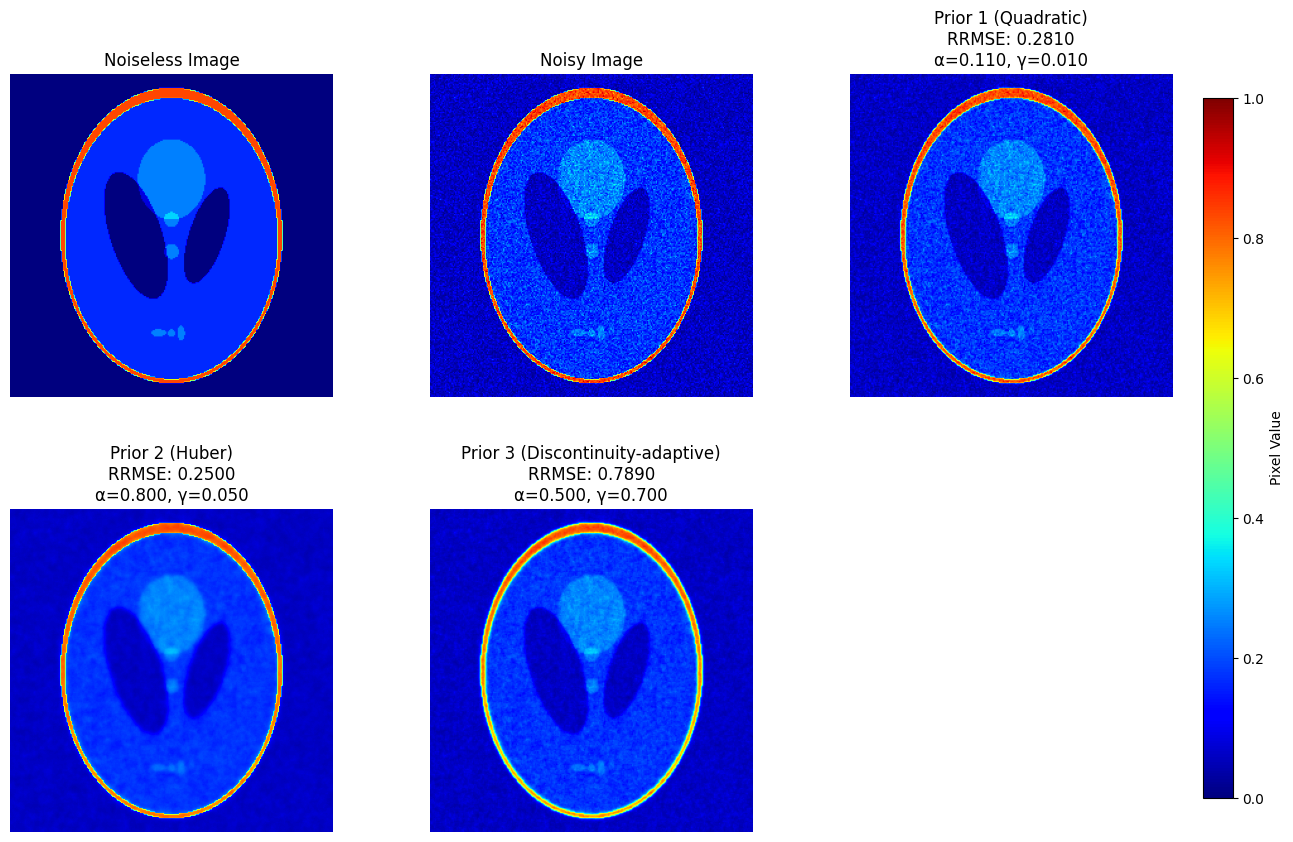

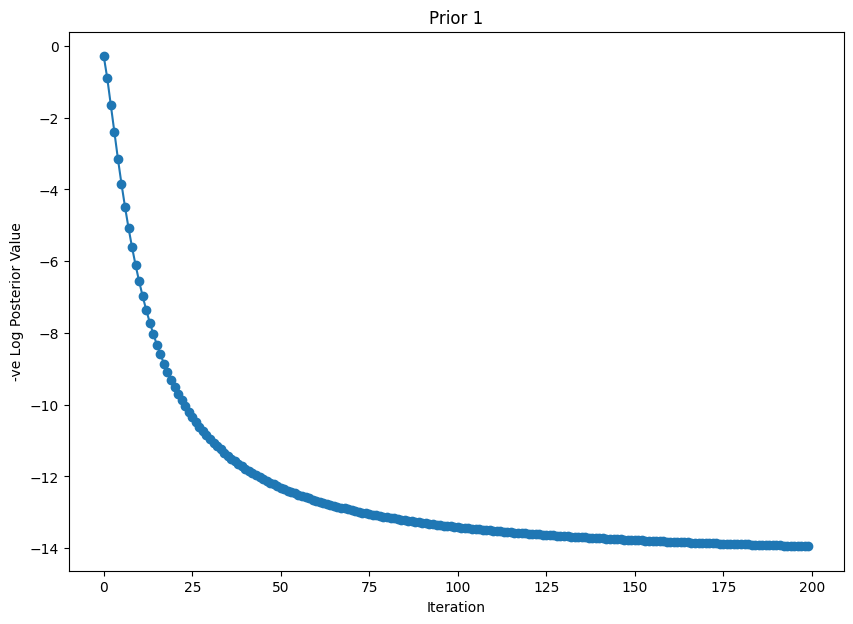

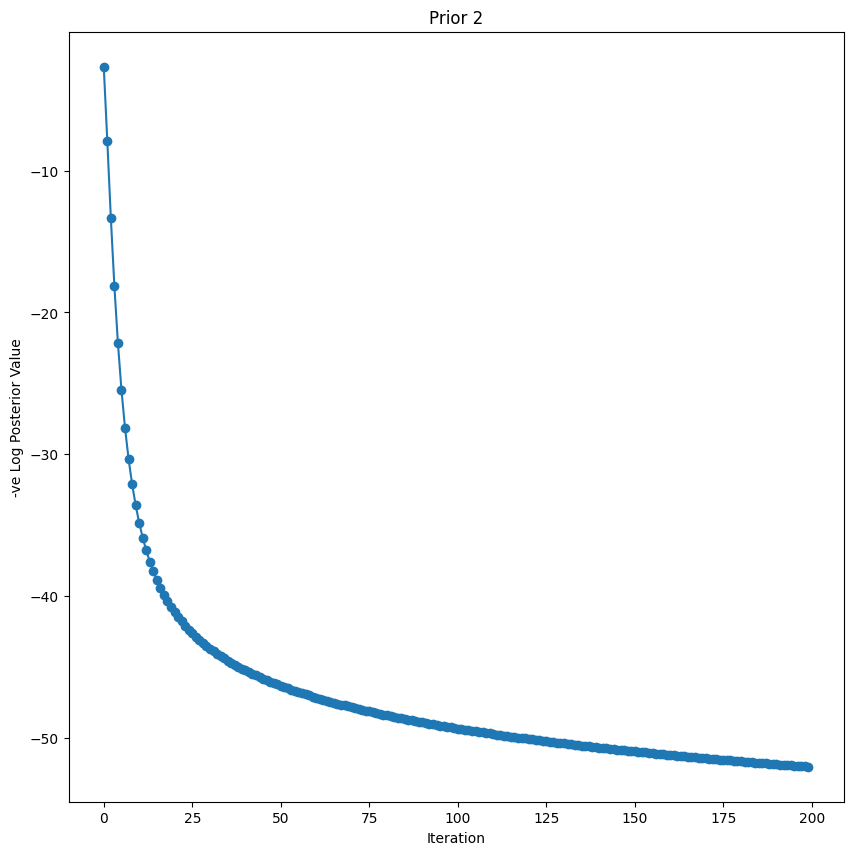

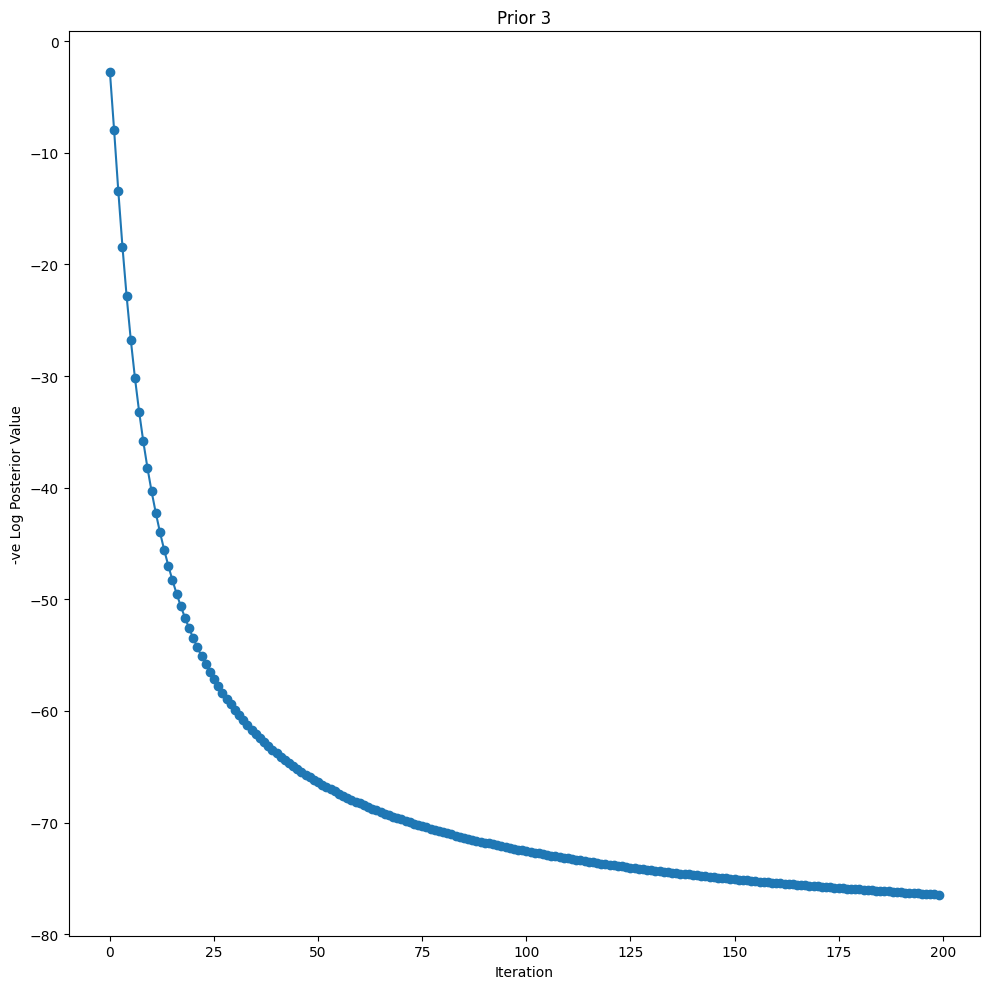

In [17]:
params = {
        'alpha1': 0.11, 'gamma1': 0.01, 'rrmse1': 0.281,  # find optimal
        'alpha2': 0.8, 'gamma2': 0.05, 'rrmse2': 0.250,
        'alpha3': 0.5, 'gamma3': 0.7, 'rrmse3': 0.789 # find optimal
    }

# Get denoised images using optimal parameters
denoised1, pos1 = gradient_descent(noisy_image, prior1, params['alpha1'], params['gamma1'])
denoised2, pos2 = gradient_descent(noisy_image, prior2, params['alpha2'], params['gamma2'])
denoised3, pos3 = gradient_descent(noisy_image, prior3, params['alpha3'], params['gamma3'])

# Create the comparison plot
plot_all_results(noiseless_image, noisy_image, denoised1, denoised2, denoised3, params)
plot_posterior(pos1, pos2, pos3)